# **1. Mengumpulkan Data (J.62DMI00.004.1)**



In [ ]:
# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Load datasetdari google drive
url = "https://drive.google.com/uc?export=download&id=1uN9NJZs-QpBru23ugeVhUEXyfUtM7R5D"
df = pd.read_csv(url)

# **2. Menelaah Data (J.62DMI00.005.1)**



In [ ]:
# Informasi dataset
print("\nInformasi Dataset:")
df.info()
print("\nUkuran Dataset:", df.shape)

# Menampilkan 10 data pertama
print("10 Data Pertama:")
display(df.head(10))


Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
Index: 7021 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   object 
 1   SeniorCitizen     7021 non-null   int64  
 2   Partner           7021 non-null   object 
 3   Dependents        7021 non-null   object 
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   object 
 6   MultipleLines     7021 non-null   object 
 7   InternetService   7021 non-null   object 
 8   OnlineSecurity    7021 non-null   object 
 9   OnlineBackup      7021 non-null   object 
 10  DeviceProtection  7021 non-null   object 
 11  TechSupport       7021 non-null   object 
 12  StreamingTV       7021 non-null   object 
 13  StreamingMovies   7021 non-null   object 
 14  Contract          7021 non-null   object 
 15  PaperlessBilling  7021 non-null   object 
 16  PaymentMethod     7021 non-

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
6,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
7,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
8,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


# **3. Memvalidasi Data (J.62DMI00.006.1)**



In [ ]:
# Cek missing value
print("\nMissing Value:")
print(df.isnull().sum())

# Cek duplikasi data
print("\nJumlah Duplikasi:", df.duplicated().sum())



Missing Value:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Jumlah Duplikasi: 0


# **4. Menentukan Objek Data (J.62DMI00.007.1)**



In [ ]:
# Kolom kategorikal dan Numerik
kolom_kategorikal = df.select_dtypes(include=['object']).columns.tolist()
kolom_numerik = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Kolom Kategorikal:")
print(kolom_kategorikal)

print("\nKolom Numerik:")
print(kolom_numerik)

#Identifikasi target
print("Distribusi Target Churn:")
print(df['Churn'].value_counts())

Kolom Kategorikal:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']

Kolom Numerik:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Distribusi Target Churn:
Churn
No     5153
Yes    1857
Name: count, dtype: int64


# **5. Membersihkan Data (J.62DMI00.008.1)**



In [ ]:
# Menghapus kolom yang tidak perlu
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

print("Kolom Setelah Hapus customerID:")
print(df.columns.tolist())

# Memperbaiki tipe data pada kolom TotalCharges
df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("Tipe Data Setelah Perbaikan:")
print(df.dtypes)

# Cek ulang missing value
print("Missing Value Setelah Cleaning:")
print(df.isnull().sum())

# Hapus missing value
df = df.dropna()

# Hapus duplikat
df = df.drop_duplicates()

print("Ukuran Dataset Setelah Hapus Missing Value dan Duplikat:", df.shape)

Kolom Setelah Hapus customerID:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
Tipe Data Setelah Perbaikan:
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object
Missing Value Setelah Cleaning:
gender              0
S

# **6. Mengkonstruksi Data (J.62DMI00.009.1)**



In [ ]:
# Pisahkan fitur dan target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Encode target
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

print("Mapping Target:")
for i, kelas in enumerate(label_encoder.classes_):
    print(f"{kelas} -> {i}")

# Identifikasi fitur numerik dan kategorikal
fitur_kategorikal = X.select_dtypes(include=['object']).columns.tolist()
fitur_numerik = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Fitur Kategorikal:", fitur_kategorikal)
print("Fitur Numerik:", fitur_numerik)

# Preprocessing numerik
transformer_numerik = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocessing kategorikal
transformer_kategorikal = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Menggabungkan preprocessing
preprocessor = ColumnTransformer(transformers=[
    ('num', transformer_numerik, fitur_numerik),
    ('cat', transformer_kategorikal, fitur_kategorikal)
])

Mapping Target:
No -> 0
Yes -> 1
Fitur Kategorikal: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Fitur Numerik: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


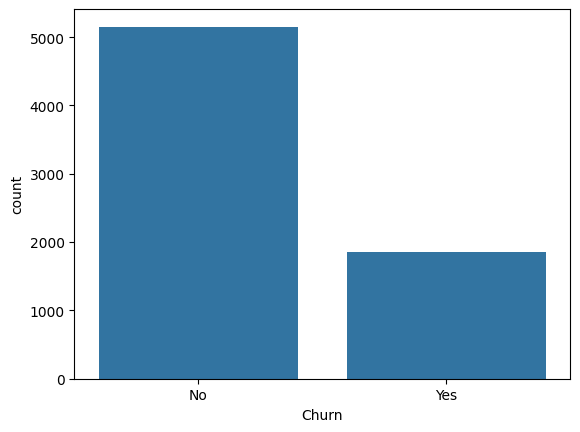

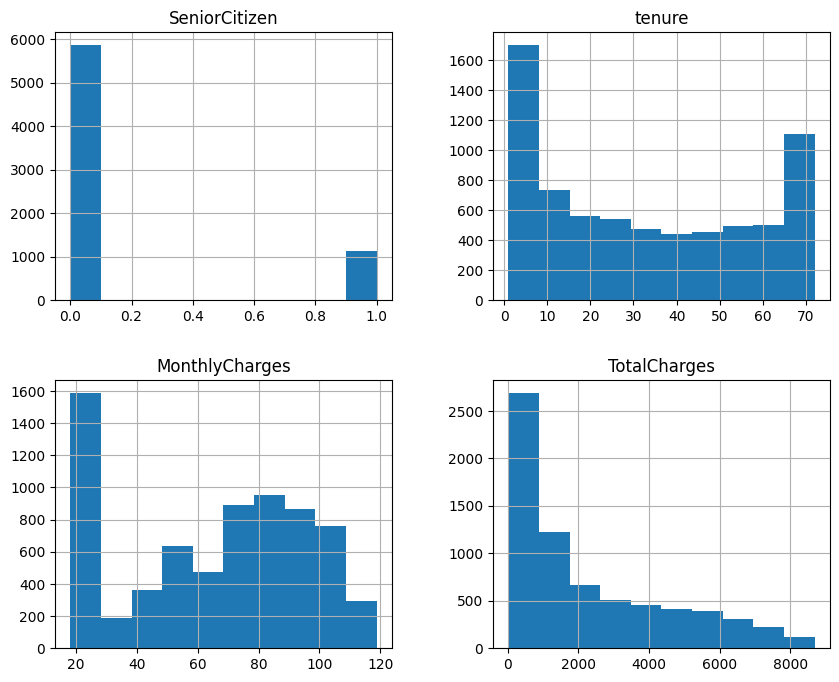

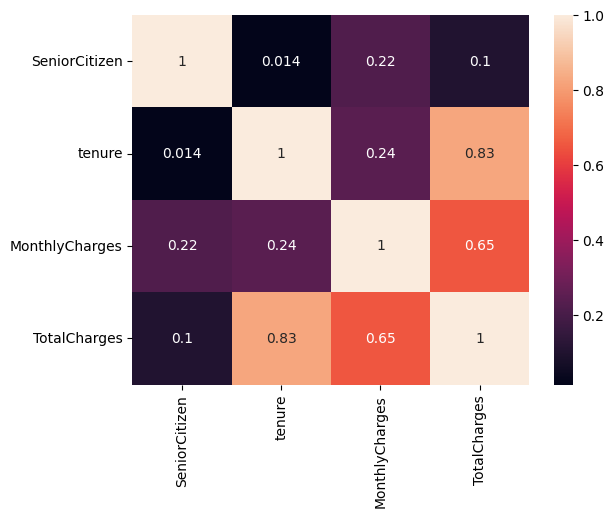

In [ ]:
# Visualisasi

# 1. Distribusi target
sns.countplot(x='Churn', data=df)
plt.show()

# 2. Histogram
df.hist(figsize=(10,8))
plt.show()

# 3. Korelasi
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

# **7. Menentukan Label Data (J.62DMI00.010.1)**



In [ ]:
print("Label Data / Target Adalah Kolom 'Churn'")
print("Kelas target:")
print(df['Churn'].value_counts())

Label Data / Target Adalah Kolom 'Churn'
Kelas target:
Churn
No     5153
Yes    1857
Name: count, dtype: int64


# **8. Membangun Model (J.62DMI00.013.1)**



In [ ]:
# Split data train-test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test :", X_test.shape)

# Model 1 logistic regression
model_logistic = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])
model_logistic.fit(X_train, y_train)
y_pred_logistic = model_logistic.predict(X_test)

# Model 2 random forest
model_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=200, random_state=42))
])
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

Ukuran X_train: (5608, 19)
Ukuran X_test : (1402, 19)


# **9. Mengevaluasi Hasil Pemodelan (J.62DMI00.014.1)**



Accuracy Logistic Regression: 0.8081312410841655
              precision    recall  f1-score   support

          No       0.85      0.90      0.87      1031
         Yes       0.67      0.54      0.60       371

    accuracy                           0.81      1402
   macro avg       0.76      0.72      0.74      1402
weighted avg       0.80      0.81      0.80      1402



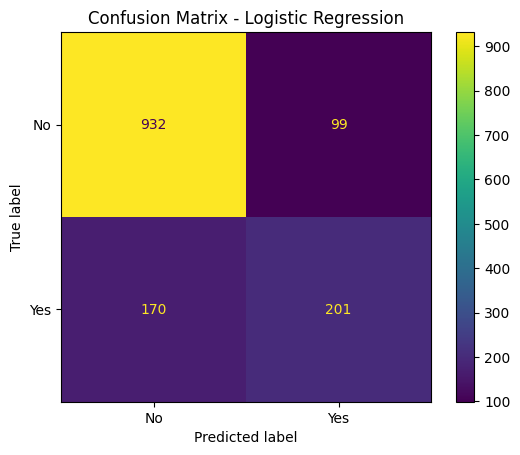

Accuracy Random Forest: 0.7895863052781741
              precision    recall  f1-score   support

          No       0.83      0.90      0.86      1031
         Yes       0.63      0.48      0.55       371

    accuracy                           0.79      1402
   macro avg       0.73      0.69      0.71      1402
weighted avg       0.78      0.79      0.78      1402



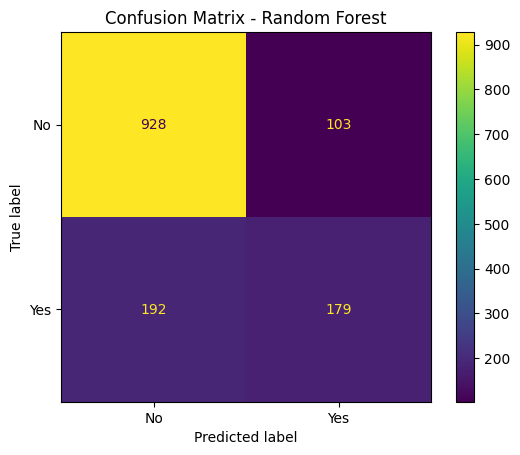

,Model,Accuracy
0,Logistic Regression,0.808131
1,Random Forest,0.789586


Model terbaik adalah: Logistic Regression


In [ ]:
# Evaluasi logistic regression
acc_logistic = accuracy_score(y_test, y_pred_logistic)
print("Accuracy Logistic Regression:", acc_logistic)
print(classification_report(y_test, y_pred_logistic, target_names=label_encoder.classes_))

cm_logistic = confusion_matrix(y_test, y_pred_logistic)
disp_logistic = ConfusionMatrixDisplay(confusion_matrix=cm_logistic, display_labels=label_encoder.classes_)
disp_logistic.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# Evaluasi random forest
acc_rf = accuracy_score(y_test, y_pred_rf)
print("Accuracy Random Forest:", acc_rf)
print(classification_report(y_test, y_pred_rf, target_names=label_encoder.classes_))

cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=label_encoder.classes_)
disp_rf.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

# Perbandingan model
hasil_model = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [acc_logistic, acc_rf]
})

display(hasil_model)

model_terbaik = "Random Forest" if acc_rf > acc_logistic else "Logistic Regression"
print("Model terbaik adalah:", model_terbaik)

# **Uji Coba Model**



In [ ]:
data_baru = pd.DataFrame([{
    'gender': 'Female',
    'SeniorCitizen': 0,
    'Partner': 'Yes',
    'Dependents': 'No',
    'tenure': 12,
    'PhoneService': 'Yes',
    'MultipleLines': 'No',
    'InternetService': 'Fiber optic',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'Yes',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'Yes',
    'StreamingMovies': 'Yes',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 79.85,
    'TotalCharges': 956.40
}])

best_model = model_rf if acc_rf > acc_logistic else model_logistic
hasil_prediksi = best_model.predict(data_baru)
hasil_label = label_encoder.inverse_transform(hasil_prediksi)

print("Hasil prediksi churn:", hasil_label[0])

Hasil prediksi churn: Yes


# **Kesimpulan**





*   Model machine learning yang digunakan yaitu Logistic Regression dan Random Forest, dimana Random Forest menunjukkan performa yang lebih baik berdasarkan nilai akurasi.

*   Model ini dapat dikembangkan lebih lanjut dengan penambahan fitur lain, penggunaan algoritma yang lebih kompleks, serta integrasi dengan data real-time untuk meningkatkan akurasi prediksi.

